In [1]:
import os

notebook_dir = r"c:\Users\zhibo.zhu\OneDrive - UIH Group\Documents\Jupyter\spiral"
os.chdir(notebook_dir)
print('Changed CWD to', os.getcwd())

Changed CWD to c:\Users\zhibo.zhu\OneDrive - UIH Group\Documents\Jupyter\spiral


In [ ]:
# Estimate memory usage for different models and configurations.
import os, sys, subprocess

models = [
    "ResidualCNN_3layers",
    "ResidualCNN_5layers",
    "ResidualCNN_5layers_withB0",
    "ResidualCNN_5layers_withPhi",
    "ResidualCNN_MSResNet_withB0",
    "MS_UNet",
    "MS_UNet_4stage",
]
model_n = {
    "ResidualCNN_3layers": ["64", "32"],
    "ResidualCNN_5layers": ["64", "64", "64", "32"],
    "ResidualCNN_5layers_withB0": ["64", "64", "64", "32"],
    "ResidualCNN_5layers_withPhi": ["64", "64", "64", "32"],
    "ResidualCNN_MSResNet_withB0": ["64", "64", "64", "64", "64"],
    "MS_UNet": ["64", "128"],
    "MS_UNet_4stage": ["64", "128", "256", "512", "512"],
}
batch = "8"
H = "208"
W = "208"
model_f = {
    "ResidualCNN_3layers": ["9", "5"],
    "ResidualCNN_5layers": ["5", "5", "5", "5", "5"],
    "ResidualCNN_5layers_withB0": ["5", "5", "5", "5", "5"],
    "ResidualCNN_5layers_withPhi": ["5", "5", "5", "5", "5"],
    "ResidualCNN_MSResNet_withB0": ["5", "3", "5", "7", "5"],
    "MS_UNet": ["3", "5", "7"],
    "MS_UNet_4stage": ["3", "5", "7"],
}

# print('CWD:', os.getcwd())
# print('estimate_model_memory.py exists:', os.path.exists('estimate_model_memory.py'))
# print('Python executable:', sys.executable)
for m in models:
    f_args = model_f.get(m, ["3", "3"])
    n_args = model_n.get(m, ["64", "32"])
    cmd = [sys.executable, "estimate_model_memory.py",
           "--model", m,
           "--batch", batch,
           "--height", H, "--width", W,
    ] + ["--f"] + f_args + ["--n"] + n_args
    print("Running:", " ".join(cmd))
    env = os.environ.copy()
    env['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
    proc = subprocess.run(cmd, env=env, capture_output=True, text=True)
    print(proc.stdout)
    # if proc.stderr:
    #     print('STDERR:', proc.stderr)
    # if proc.returncode != 0:
    #     print(f'Command failed for {m} with return code {proc.returncode}')
    #     break

Running: c:\ProgramData\anaconda3\python.exe estimate_model_memory.py --model ResidualCNN_3layers --batch 8 --height 208 --width 208 --f 9 5 --n 64 32
Model: ResidualCNN_3layers
Batch size: 8
Input shape: 2x208x208 (C x H x W)
Kernel sizes f: [9, 5]
Channel sizes n: [64, 32]
Parameter count: 61730
Parameter memory: 0.12 MiB (float16)
Activation memory: 64.70 MiB (float16)
Optimizer state memory: 0.24 MiB (optimizer=adam)
Forward estimate: 64.81 MiB
Backprop estimate: 65.17 MiB

Note: This is a rough estimate and does not include CUDA workspace, data loader buffers, or other library overhead.

Running: c:\ProgramData\anaconda3\python.exe estimate_model_memory.py --model ResidualCNN_5layers --batch 8 --height 208 --width 208 --f 5 5 5 5 5 --n 64 64 64 32
Model: ResidualCNN_5layers
Batch size: 8
Input shape: 2x208x208 (C x H x W)
Kernel sizes f: [5, 5, 5, 5, 5]
Channel sizes n: [64, 64, 64, 32]
Parameter count: 261026
Parameter memory: 0.50 MiB (float16)
Activation memory: 149.20 MiB (flo

In [ ]:
# Conventional spiral MRI reconstruction pipeline with GIRF and off-resonance correction.
import importlib
import numpy as np
import demo_spi_recon
importlib.reload(demo_spi_recon)

# In-vivo
fname = "//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol2/17779975170000/"
file_name = fname + "UID_7636259313200819710_vds48_fs.raw" # UID_7633693211975291951_vds48_fs
prot_name = fname + "UID_7636259313200819710_vds48_fs.prot" # UID_7633693211975291951_vds48_fs
npy_name = fname + "UID_7636259313200819710_K/k_1690x48x80x1_CHA34_Ech0_Set0_Rep0_Ave0_UD_0_0_0_0_0.npy" # UID_7633693211975291951_K/k_1690x48x80x1_CHA34_Ech0_Set0_Rep0_Ave0_UD_0_0_0_0_0.npy
b0map_name = "//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/image/jupiter/20260505/spiral_vol_zz_20260505_20260505-110021-0434_110059/gre__b0map_3d_B0Map_110504_203"

fmax = 1000
L, B, P = 15, 8, 4
img_no_girf, img_girf, img_MFI_final, img_MFI, img_IR, cleaned_map, spi_recon_obj = demo_spi_recon.run_pipeline(file_name, prot_name, npy_name, b0map_name, fmax, L, B, P)

Calculating analytical DCF ...
Calculating analytical DCF done.
2D spiral generated


AttributeError: 'NoneType' object has no attribute 'text'

In [ ]:
# Save results
from pathlib import Path

Path(fname + "images").mkdir(parents=True, exist_ok=True)
np.save(fname + 'images/img_no_girf.npy', img_no_girf)
np.save(fname + 'images/img_girf.npy', img_girf)
np.save(fname + 'images/img_MFI_final.npy', img_MFI_final)
np.save(fname + 'images/img_IR.npy', img_IR)
np.save(fname + 'images/cleaned_map.npy', cleaned_map)
np.save(fname + 'images/spi_recon_obj.npy', spi_recon_obj)

In [1]:
import numpy as np

folders = ["17779974700000", "17779975170000", "17779969610000"]
# no_girf_name = lambda x: f"//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol1/{x}/images/img_no_girf.npy"
girf_name = lambda x: f"//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol2/{x}/images/img_girf.npy"
MFI_name = lambda x: f"//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol2/{x}/images/img_MFI_final.npy"
IR_name = lambda x: f"//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol2/{x}/images/img_IR.npy"
B0_name = lambda x: f"//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol2/{x}/images/cleaned_map.npy"
spi_recon_obj_name = lambda x: f"//10.31.10.207/uiha-mr/UIHA_MRScanner/zhibozhu/rawdata/jupiter/spiral/20260505/vol2/{x}/images/spi_recon_obj.npy"

# img_no_girf = np.stack([np.load(no_girf_name(folders[0])), np.load(no_girf_name(folders[1]))])
spi_recon_obj = np.load(spi_recon_obj_name(folders[0]), allow_pickle=True).item()
img_girf = np.stack([np.load(girf_name(folders[0])), np.load(girf_name(folders[1])), np.load(girf_name(folders[2]))])
img_MFI_final = np.stack([np.load(MFI_name(folders[0])), np.load(MFI_name(folders[1])), np.load(MFI_name(folders[2]))])
img_IR = np.stack([np.load(IR_name(folders[0])), np.load(IR_name(folders[1])), np.load(IR_name(folders[2]))])
cleaned_map = np.stack([np.load(B0_name(folders[0])), np.load(B0_name(folders[1])), np.load(B0_name(folders[2]))])

# Magical (in fact mathematical) scaling factor is here!
print(f"Short RO norm: {np.linalg.norm(img_girf[0, ...])}")
print(f"Medium RO norm: {np.linalg.norm(img_girf[1, ...])}")
print(f"Long RO norm: {np.linalg.norm(img_girf[2, ...])}")
print(f"MFI target norm: {np.linalg.norm(img_MFI_final[0, ...])}")
print(f"IR target norm: {np.linalg.norm(img_IR[0, ...])}")
print(f"IR target norm after scaling: {np.linalg.norm(img_IR[0, ...]) / (np.sqrt(img_girf.shape[-1]) / np.sqrt(img_girf.shape[1]*img_girf.shape[2]) / np.mean(spi_recon_obj.get_obj().dcf))}")
print(f"Short RO input / MFI target norm: {100 * np.linalg.norm(img_girf[0, ...]) / np.linalg.norm(img_MFI_final[0, ...])}%")
print(f"Medium RO input / MFI target norm: {100 * np.linalg.norm(img_girf[1, ...]) / np.linalg.norm(img_MFI_final[0, ...])}%")
print(f"Long RO input / MFI target norm: {100 * np.linalg.norm(img_girf[2, ...]) / np.linalg.norm(img_MFI_final[0, ...])}%")
print(f"Short RO input / IR target norm: {100 * np.linalg.norm(img_girf[0, ...]) / (np.linalg.norm(img_IR[0, ...]) / (np.sqrt(img_girf.shape[-1]) / np.sqrt(img_girf.shape[1]*img_girf.shape[2]) / np.mean(spi_recon_obj.get_obj().dcf)))}%")
print(f"Medium RO input / IR target norm: {100 * np.linalg.norm(img_girf[1, ...]) / (np.linalg.norm(img_IR[0, ...]) / (np.sqrt(img_girf.shape[-1]) / np.sqrt(img_girf.shape[1]*img_girf.shape[2]) / np.mean(spi_recon_obj.get_obj().dcf)))}%")
print(f"Long RO input / IR target norm: {100 * np.linalg.norm(img_girf[2, ...]) / (np.linalg.norm(img_IR[0, ...]) / (np.sqrt(img_girf.shape[-1]) / np.sqrt(img_girf.shape[1]*img_girf.shape[2]) / np.mean(spi_recon_obj.get_obj().dcf)))}%")

Short RO norm: 25083137582.38267
Medium RO norm: 23333724701.77982
Long RO norm: 22269934141.686512
MFI target norm: 25181058740.12944
IR target norm: 1889035264.0
IR target norm after scaling: 22203375736.43838
Short RO input / MFI target norm: 99.61113168926961%
Medium RO input / MFI target norm: 92.66379520649129%
Long RO input / MFI target norm: 88.43922875330236%
Short RO input / IR target norm: 112.96992799711198%
Medium RO input / IR target norm: 105.09088788461297%
Long RO input / IR target norm: 100.29976705361474%


<Figure size 640x480 with 0 Axes>

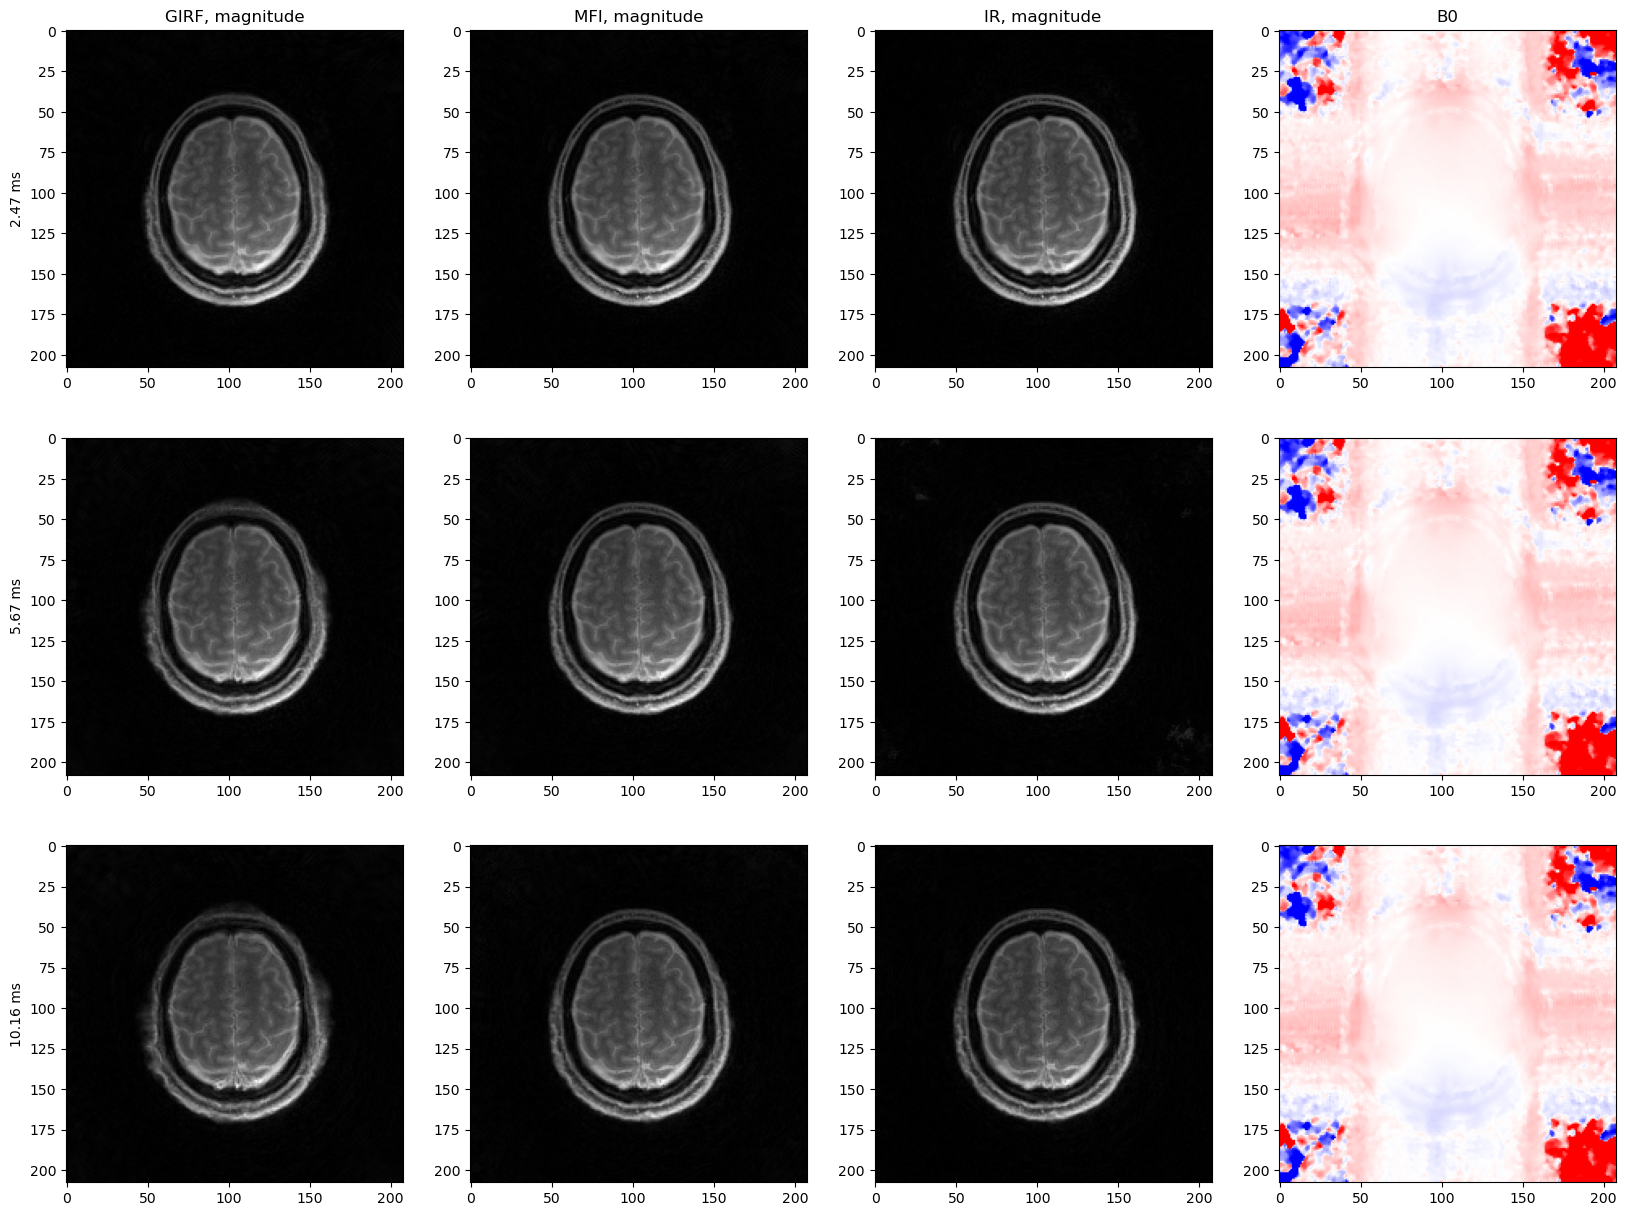

<Figure size 640x480 with 0 Axes>

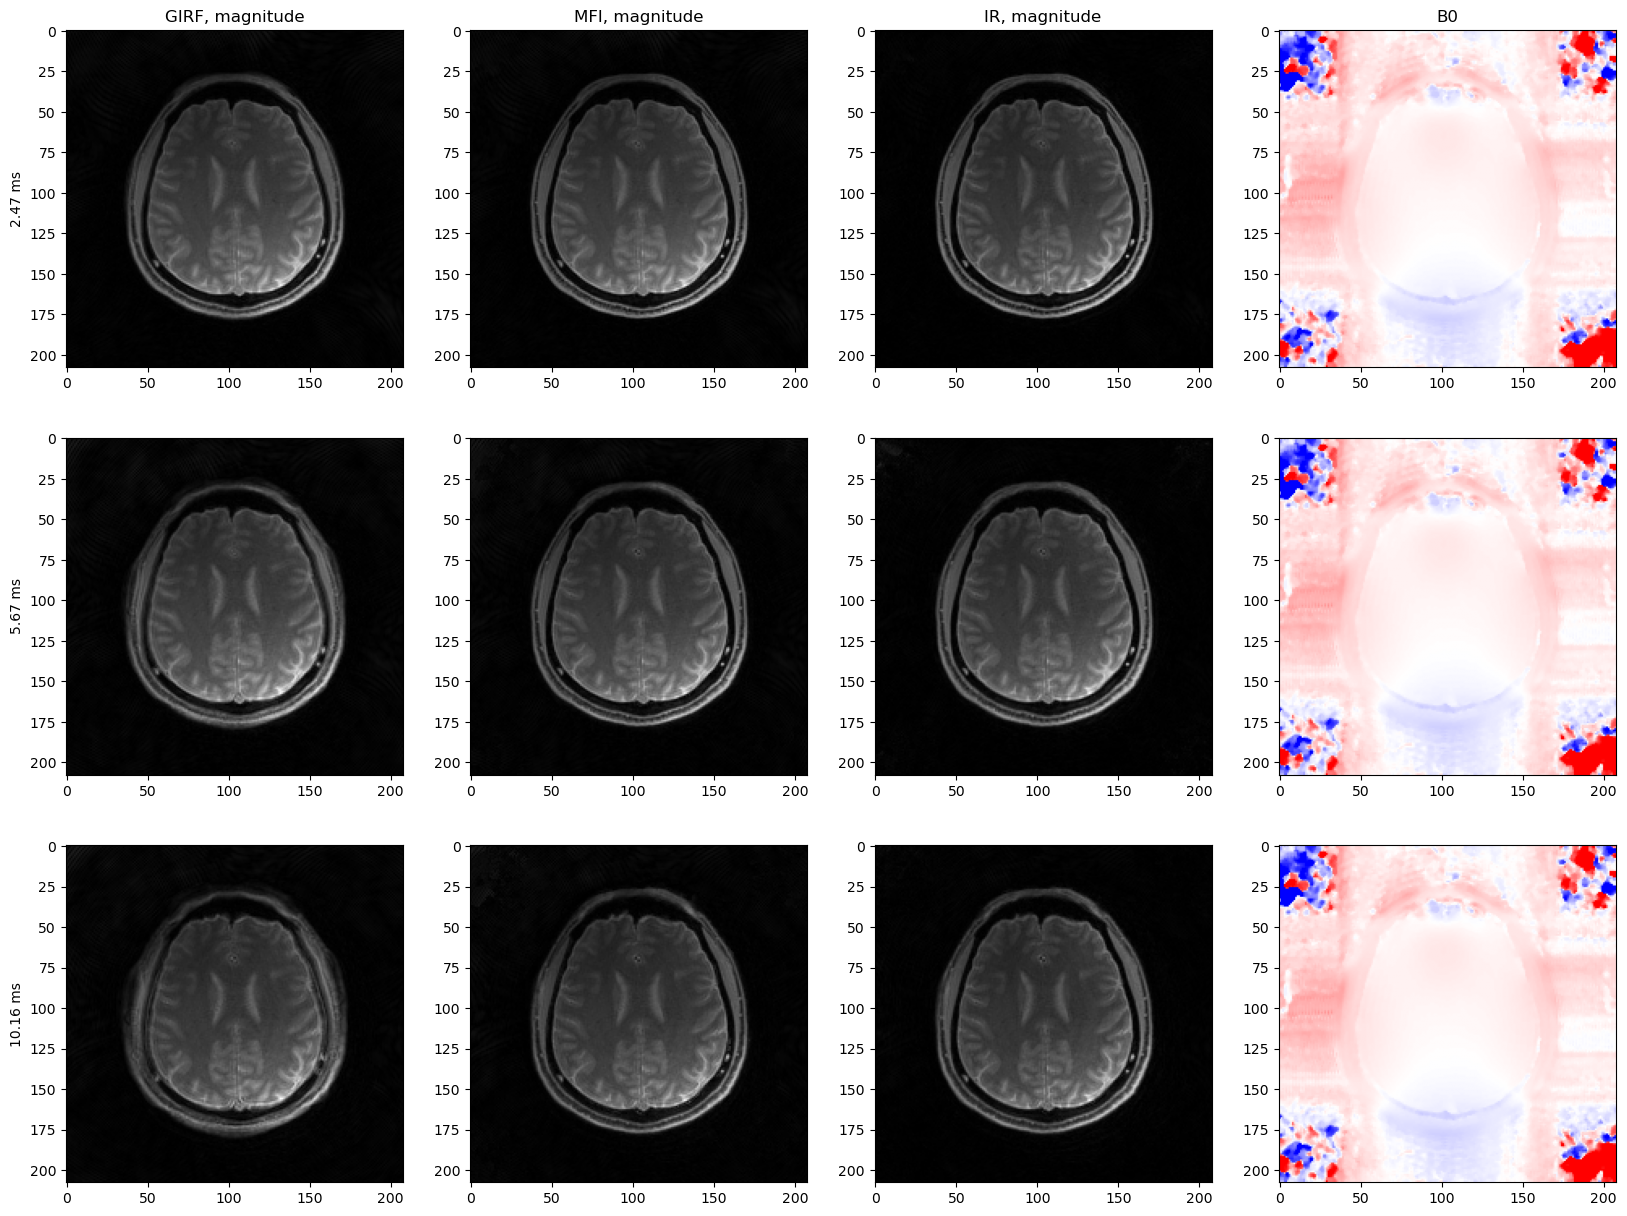

<Figure size 640x480 with 0 Axes>

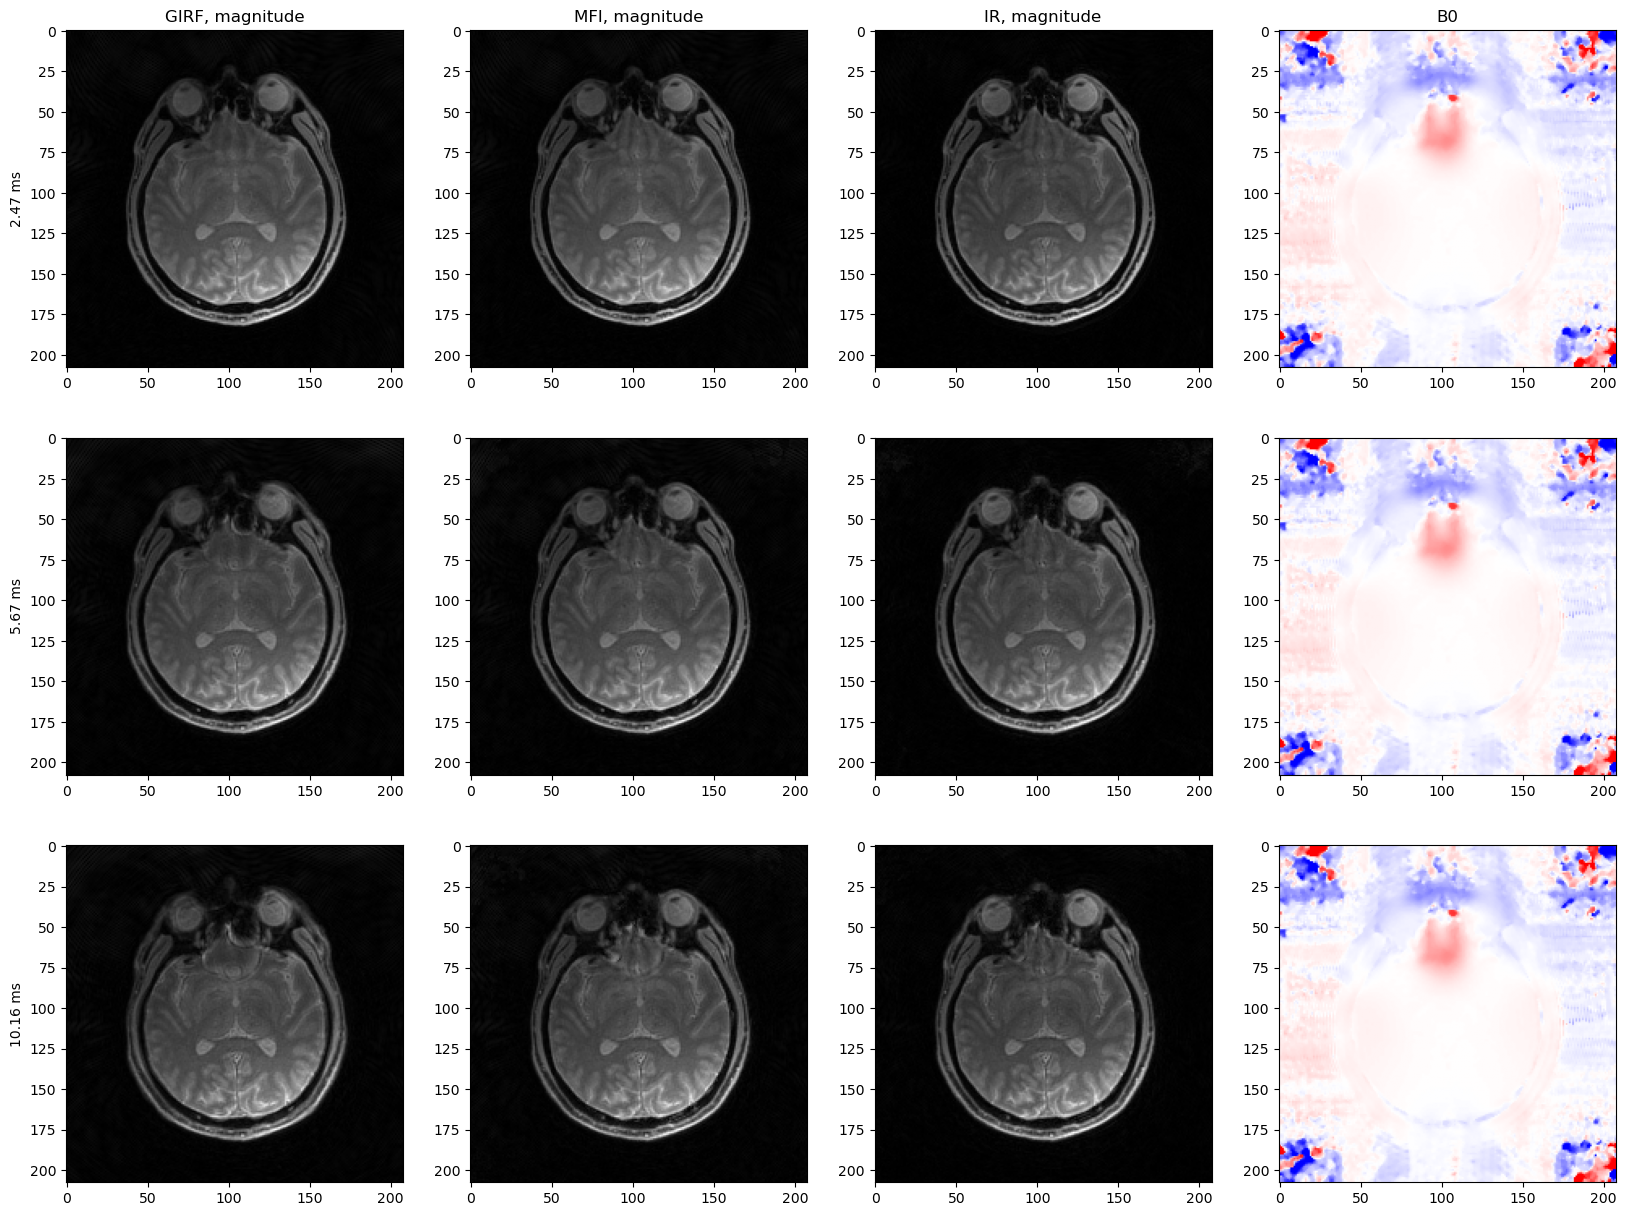

<Figure size 640x480 with 0 Axes>

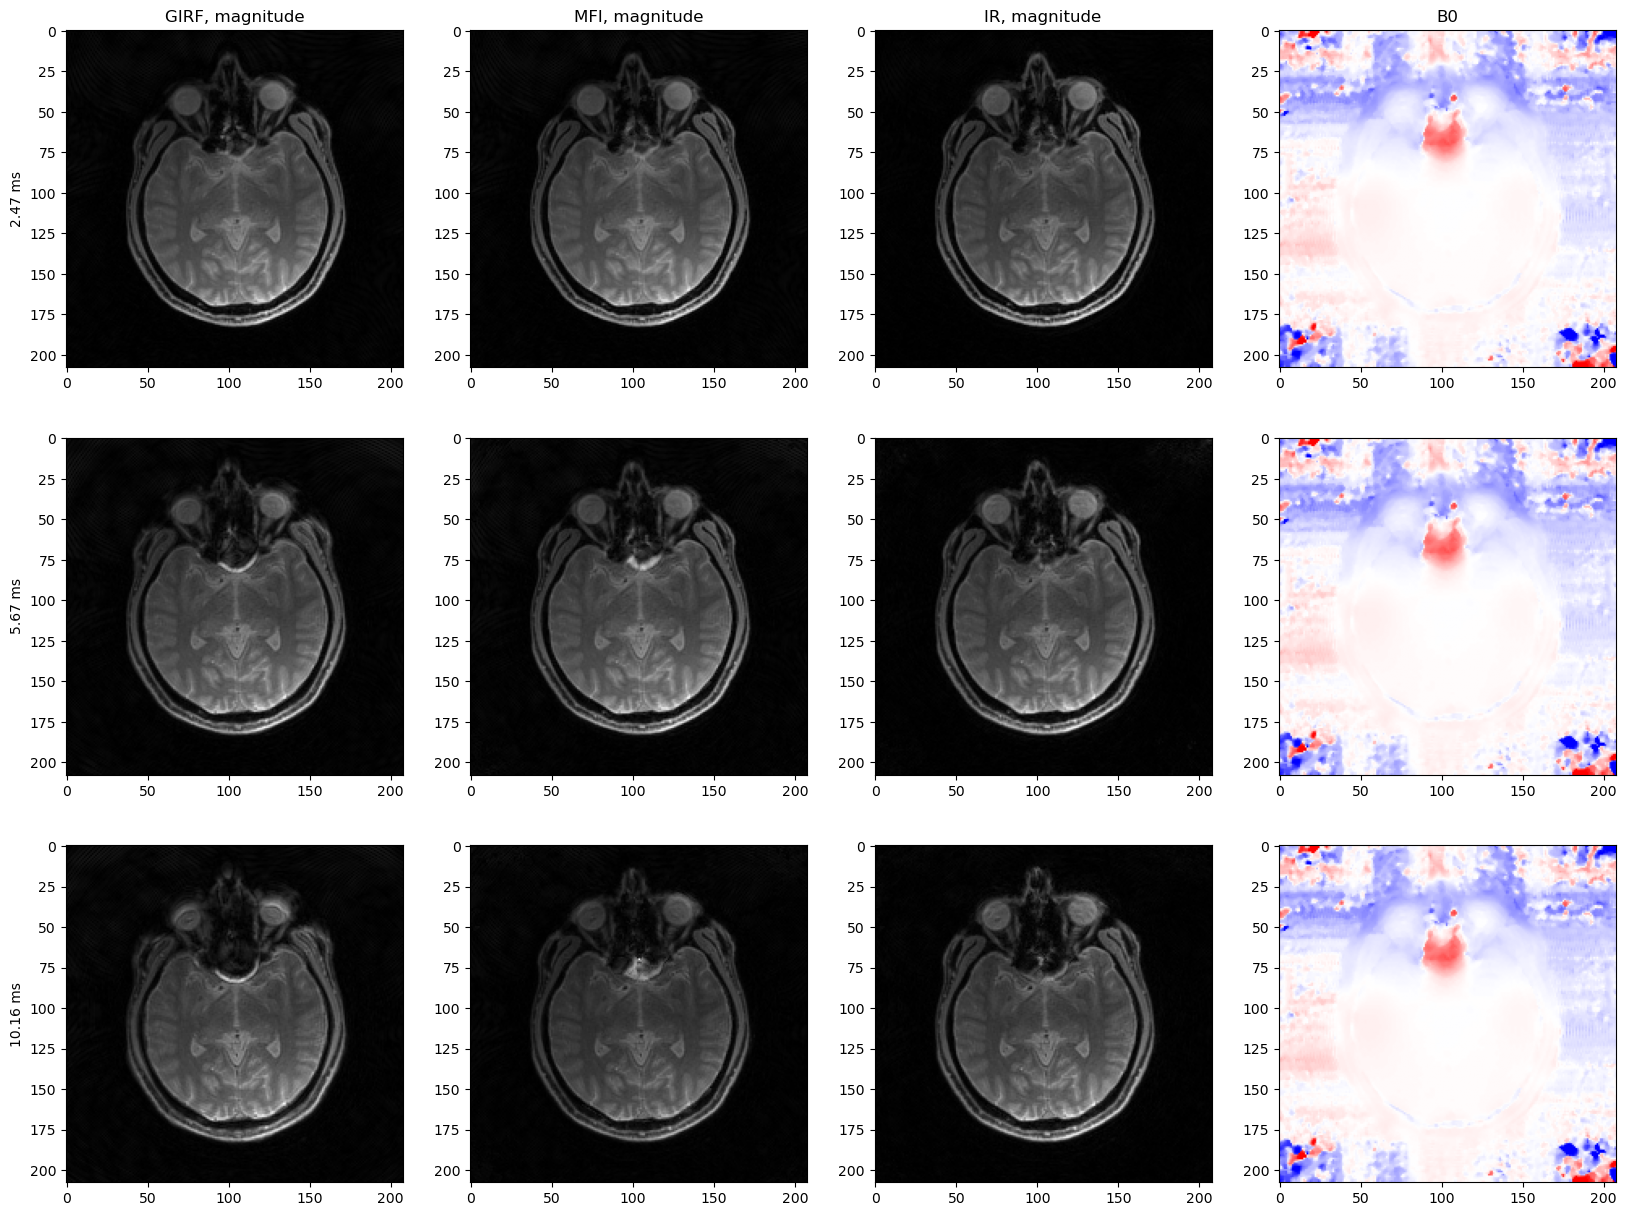

In [2]:
# Visualize
import matplotlib.pyplot as plt

ns = [20, 30, 40, 43]

for ii in range(len(ns)):
    plt.figure()
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    for jj in range(3):
        # axes[ii*2+jj][0].imshow(np.transpose(np.abs(img_no_girf[jj, ..., ns[ii]])), cmap='grey')
        axes[jj][0].imshow(np.transpose(np.abs(img_girf[jj, ..., ns[ii]])), cmap='grey')
        axes[jj][1].imshow(np.transpose(np.abs(img_MFI_final[jj, ..., ns[ii]])), cmap='grey')
        axes[jj][2].imshow(np.transpose(np.abs(img_IR[jj, ..., ns[ii]])), cmap='grey')
        axes[jj][3].imshow(np.transpose(cleaned_map[jj, ..., ns[ii]]), cmap='bwr', vmin=-800, vmax=800)
    axes[0][0].set_ylabel("2.47 ms")
    axes[1][0].set_ylabel("5.67 ms")
    axes[2][0].set_ylabel("10.16 ms")

    # axes[0][0].set_title("No GIRF, magnitude")
    axes[0][0].set_title("GIRF, magnitude")
    axes[0][1].set_title("MFI, magnitude")
    axes[0][2].set_title("IR, magnitude")
    axes[0][3].set_title("B0")

    # plt.savefig(f"spiral_baselines_ns{ns[ii]}.png")
    plt.show()

In [3]:
# Foreground masking.
from generate_3d_convex_mask import generate_3d_convex_mask

mask1 = generate_3d_convex_mask(np.abs(img_girf[0, ...]), sf=0.8, dilation_voxels=5)
mask2 = generate_3d_convex_mask(np.abs(img_girf[1, ...]), sf=0.8, dilation_voxels=5)
mask3 = generate_3d_convex_mask(np.abs(img_girf[2, ...]), sf=0.8, dilation_voxels=5)
mask = np.stack([mask1, mask2, mask3])
print(mask.shape)

(3, 208, 208, 80)


<Figure size 640x480 with 0 Axes>

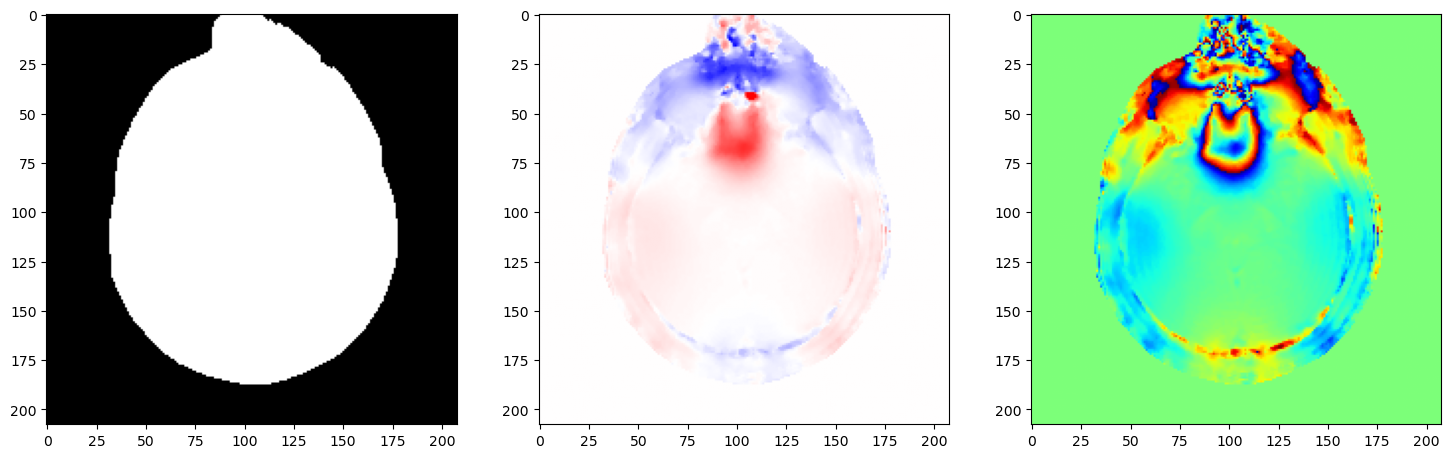

In [4]:
# Prepare B0 and Phi (phasor) as a part of training data.
B0 = cleaned_map * mask
Phi = np.exp(-1j * 2 * np.pi * spi_recon_obj.get_obj().dwell_time[-1] * B0)
sf_B0 = np.max(np.abs(B0))
B0 /= sf_B0

plt.figure()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(np.transpose(mask[0, ..., 40]), cmap='grey')
axes[1].imshow(np.transpose(B0[0, ..., 40]), cmap='bwr', vmin=-0.3, vmax=0.3)
axes[2].imshow(np.transpose(np.angle(Phi[0, ..., 40])), cmap='jet', vmin=-np.pi, vmax=np.pi)
plt.show()

In [5]:
from spiral_train_dataset import spi_train_dataset
from AugmentedMRIDataset import AugmentedMRIDataset
from torch.utils.data import DataLoader

# Pick training slices and perform data normalization.
# Phantom
ns = [17, 18, 19, 20, 22, 23, 24, 25, 26, 27, 30, 32, 33, 34, 35, 36,37,38,39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 55,  56, 57, 58, 59]
# In-vivo
ns = [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
ns = [ii for ii in range(15, 66)]
print(img_girf.shape)
input_data = img_girf[1, ...] # 0: Short, 1: Medium, 2: Long
input_data = input_data[..., ns]
# input_data = img_girf[..., ns]
# target_data = img_MFI_final[0, ...] * mask[0, ...]
sf_IR = (np.sqrt(img_girf.shape[-1]) / np.sqrt(img_girf.shape[1]*img_girf.shape[2]) / np.mean(spi_recon_obj.get_obj().dcf))
target_data = img_IR[1, ...] * mask[1, ...] / sf_IR
target_data = target_data[..., ns]
# target_data = img_IR[..., ns] * mask[..., ns]
sf = np.percentile(np.abs(input_data), 99)
input_norm = np.clip(input_data / sf, -1, 1)
target_norm = target_data / sf

input_B0 = B0[1, ...]

# There are 3 different training-target pairs:
# 1. Images' real and imaginary parts only for spiral_deblur_RestNet.ResidualCNN_3alyer(f, n) and spiral_deblur_RestNet.ResidualCNN_5alyer(f, n).
# 2. Images' real and imaginary parts, abd B0 maps for spiral_deblur_RestNet.ResidualCNN_5alyer_withB0(f, n) (RECOMMENDED).
# 3. Images' real and imaginary parts, phasor's real and imaginary parts for spiral_deblur_RestNet.ResidualCNN_5alyer_withPhi(f, n).
# input_data = np.stack((np.real(input_norm), np.imag(input_norm)), axis=3)
input_data = np.stack((np.real(input_norm), np.imag(input_norm), input_B0[..., ns]), axis=3)
# input_data = np.stack((np.real(input_norm), np.imag(input_norm), np.real(input_Phi[..., ns]), np.imag(input_Phi[..., ns])), axis=3)
target_data = np.stack((np.real(target_norm), np.imag(target_norm)), axis=3)

# There are 2 approaches to wrap training-target pairs:
# 1. Plain wrapper.
# 2. Provides random rotations and flips on the fly (RECOMMENDED).
# train_dataset = spi_train_dataset(np.permute_dims(input_data, (2, 3, 0, 1)), np.permute_dims(target_data, (2, 3, 0, 1)))
train_dataset = AugmentedMRIDataset(np.permute_dims(input_data, (2, 3, 0, 1)), np.permute_dims(target_data, (2, 3, 0, 1)))
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
print(train_dataset.inputs.shape)

(3, 208, 208, 80)
torch.Size([51, 3, 208, 208])


C:\Users\zhibo.zhu\AppData\Local\Temp\ipykernel_208772\949320065.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes[0][3].imshow(np.transpose(np.abs(train_dataset.inputs[n, 0, ...] + 1j * train_dataset.inputs[n, 1, ...])), cmap='gray', vmin=0, vmax=1)
C:\Users\zhibo.zhu\AppData\Local\Temp\ipykernel_208772\949320065.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes[1][3].imshow(np.transpose(np.abs(train_dataset.targets[n, 0, ...] + 1j * train_dataset.targets[n, 1, ...])), cmap='gray', vmin=0, vmax=1)


<function matplotlib.pyplot.show(close=None, block=None)>

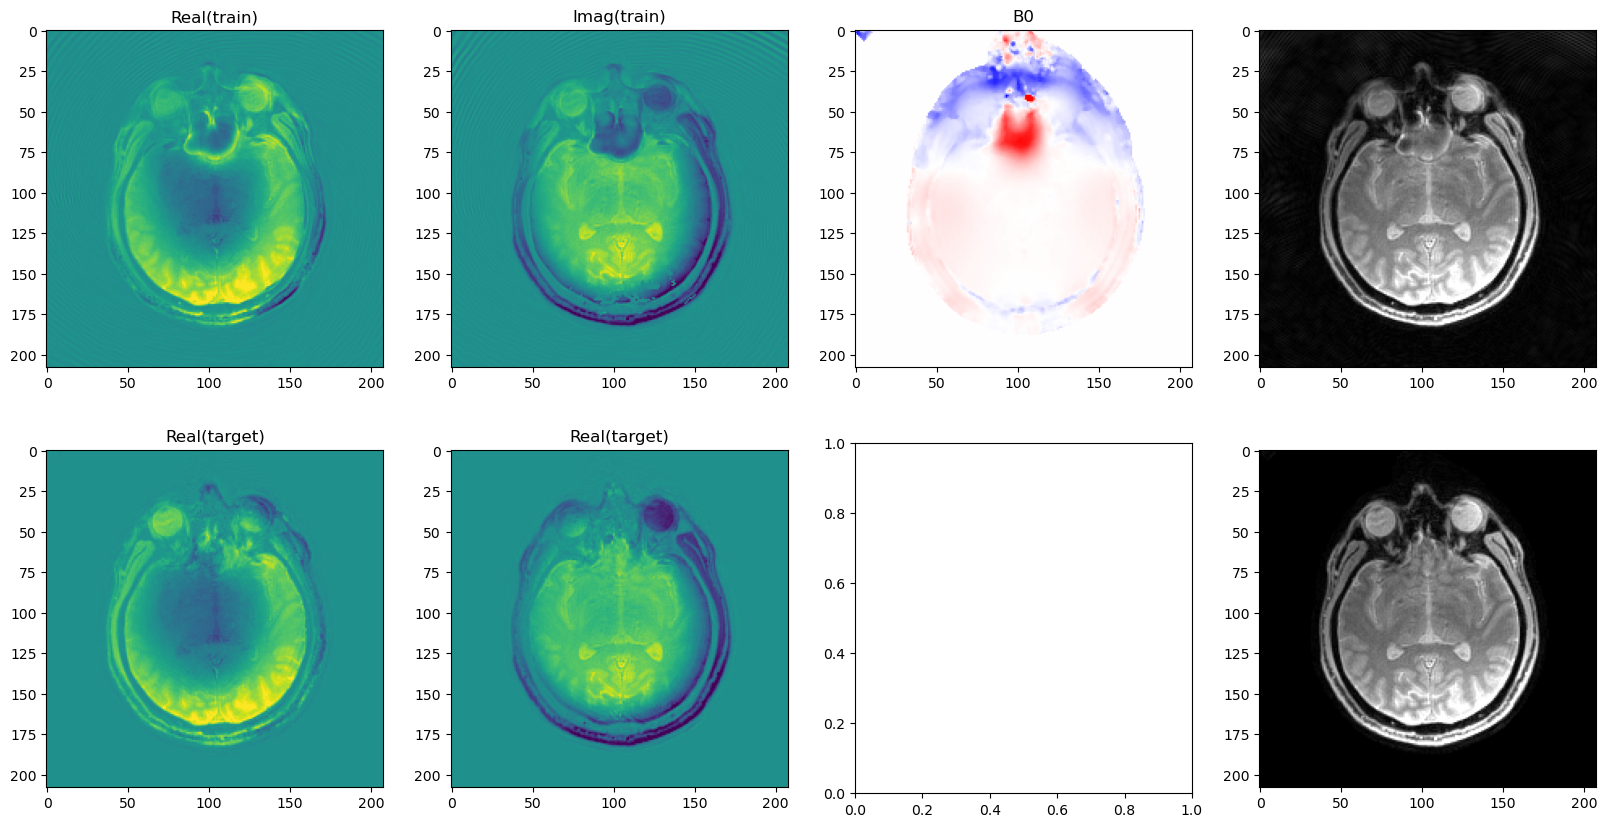

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# For Sanity check. Note that axes[0][2] should be either the B0 map or the phasor map.
n = 14
n = 26
plt.figure
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes[0][0].imshow(np.transpose(train_dataset.inputs[n, 0, ...]), vmin=-1, vmax=1)
axes[0][1].imshow(np.transpose(train_dataset.inputs[n, 1, ...]), vmin=-1, vmax=1)
axes[0][2].imshow(np.transpose(train_dataset.inputs[n, 2, ...]), cmap='bwr', vmin=-0.3, vmax=0.3)
axes[0][3].imshow(np.transpose(np.abs(train_dataset.inputs[n, 0, ...] + 1j * train_dataset.inputs[n, 1, ...])), cmap='gray', vmin=0, vmax=1)
# axes[0][2].imshow(np.transpose(np.angle(train_dataset.inputs[n, 2, ...] + 1j * train_dataset.inputs[n, 3, ...])), cmap='jet', vmin=-np.pi, vmax=np.pi)
axes[1][0].imshow(np.transpose(train_dataset.targets[n, 0, ...]), vmin=-1, vmax=1)
axes[1][1].imshow(np.transpose(train_dataset.targets[n, 1, ...]), vmin=-1, vmax=1)
axes[1][3].imshow(np.transpose(np.abs(train_dataset.targets[n, 0, ...] + 1j * train_dataset.targets[n, 1, ...])), cmap='gray', vmin=0, vmax=1)

axes[0][0].set_title("Real(train)")
axes[0][1].set_title("Imag(train)")
axes[0][2].set_title("B0")
# axes[0][2].set_title("Angle(Phasor)")
axes[1][0].set_title("Real(target)")
axes[1][1].set_title("Real(target)")
plt.show

In [28]:
import importlib

import torch
import torch.nn as nn
import torch.optim as optim
import spiral_deblur_ResNet
importlib.reload(spiral_deblur_ResNet)
from spiral_deblur_ResNet import (
    ResidualCNN_3layers,
    ResidualCNN_5layers, 
    ResidualCNN_5layers_withB0, 
    ResidualCNN_5layers_withPhi, 
    ResidualCNN_MSResNet_withB0
)
from spiral_deblur_ResNet import train_model
import spiral_deblur_UNet
importlib.reload(spiral_deblur_UNet)
from spiral_deblur_UNet import (
    MS_UNet,
    MS_UNet_4stage
)
from loss_func import weighted_l1_loss, gradient_loss
    
# 1. Initialize Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# f = (9, 5)
# n = (64, 32)
# model = ResidualCNN_3layers(f, n).to(device)

# n = (64, 64, 64, 64)
# f = (5, 5, 5, 5, 5)
# model = ResidualCNN_5layers(f, n).to(device)
# model = ResidualCNN_5layers_withB0(f, n).to(device)
# model = ResidualCNN_5layers_withPhi(f, n).to(device)

# n = (64, 64, 64, 64, 64)
# f = (5, 3, 5, 7, 5)
# model = ResidualCNN_MSResNet_withB0(f, n).to(device)

n = (64, 64)
f = (3, 5, 7)
model = MS_UNet(f, n, skip='add').to(device)

# n = (32, 64, 128, 256, 512)
# f = (3, 5, 7)
# model = MS_UNet_4stage(f, n).to(device)

criterion_l1 = nn.L1Loss()
criterion_grad = gradient_loss()
lambda_grad = 0.1
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=50, factor=0.5, min_lr=1e-5)

# 2. Train model function.
train_model(model, train_loader, optimizer, scheduler, device, criterion_l1, weighted_l1_loss, criterion_grad, log_dir="D:/models/ms_unet_4stage", lambda_grad=0.1, epochs=2000)

--- New Best Average L1 found: 0.652889 at Epoch 1 ---
--- New Best Average L1 found: 0.357546 at Epoch 2 ---
--- New Best Average L1 found: 0.251413 at Epoch 3 ---
--- New Best Average L1 found: 0.194580 at Epoch 4 ---
--- New Best Average L1 found: 0.168768 at Epoch 5 ---
--- New Best Average L1 found: 0.142317 at Epoch 6 ---
--- New Best Average L1 found: 0.122950 at Epoch 7 ---
--- New Best Average L1 found: 0.109871 at Epoch 8 ---
--- New Best Average L1 found: 0.102245 at Epoch 9 ---
--- New Best Average L1 found: 0.097689 at Epoch 10 ---
--- New Best Average L1 found: 0.086688 at Epoch 11 ---
--- New Best Average L1 found: 0.081048 at Epoch 13 ---
--- New Best Average L1 found: 0.078664 at Epoch 14 ---
--- New Best Average L1 found: 0.075845 at Epoch 15 ---
--- New Best Average L1 found: 0.074914 at Epoch 16 ---
--- New Best Average L1 found: 0.071323 at Epoch 17 ---
--- New Best Average L1 found: 0.070698 at Epoch 18 ---
--- New Best Average L1 found: 0.068583 at Epoch 19 ---
-

In [29]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.abs().mean())

enc1.branch1.weight tensor(0.0001, device='cuda:0')
enc1.branch1.bias tensor(0.0005, device='cuda:0')
enc1.branch2.weight tensor(0.0001, device='cuda:0')
enc1.branch2.bias tensor(0.0004, device='cuda:0')
enc1.branch3.weight tensor(9.0966e-05, device='cuda:0')
enc1.branch3.bias tensor(0.0003, device='cuda:0')
enc1.fuse.weight tensor(0.0002, device='cuda:0')
enc1.fuse.bias tensor(0.0011, device='cuda:0')
enc1.residual_layer.weight tensor(0.0003, device='cuda:0')
enc1.residual_layer.bias tensor(0.0011, device='cuda:0')
enc2.branch1.weight tensor(4.9291e-05, device='cuda:0')
enc2.branch1.bias tensor(0.0003, device='cuda:0')
enc2.branch2.weight tensor(2.7709e-05, device='cuda:0')
enc2.branch2.bias tensor(0.0001, device='cuda:0')
enc2.branch3.weight tensor(1.8821e-05, device='cuda:0')
enc2.branch3.bias tensor(8.1498e-05, device='cuda:0')
enc2.fuse.weight tensor(0.0001, device='cuda:0')
enc2.fuse.bias tensor(0.0007, device='cuda:0')
dec1.branch1.weight tensor(0.0001, device='cuda:0')
dec1.bra

In [25]:
import spiral_deblur_ResNet
importlib.reload(spiral_deblur_ResNet)
from spiral_deblur_ResNet import (
    ResidualCNN_3layers,
    ResidualCNN_5layers, 
    ResidualCNN_5layers_withB0, 
    ResidualCNN_5layers_withPhi, 
    ResidualCNN_MSResNet_withB0
)

n = (64, 128)
f = (3, 5, 7)
model = MS_UNet(f, n).to("cuda")
state_dict = torch.load('./models/volunteer/spiral_deblur_ResUNet_v1_invivo.pth', weights_only=True)
model.load_state_dict(state_dict)
model.eval()

MS_UNet(
  (enc1): MS_block(
    (branch1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (branch2): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (branch3): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (fuse): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
    (residual_layer): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): MS_block(
    (branch1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (branch2): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (branch3): Conv2d(64, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (fuse): Conv2d(384, 128, kernel_size=(1, 1), stride=(1, 1))
    (residual_layer): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (dec1): MS_block(
    (branch1): Conv2d(192, 64

torch.Size([2, 3, 208, 208])


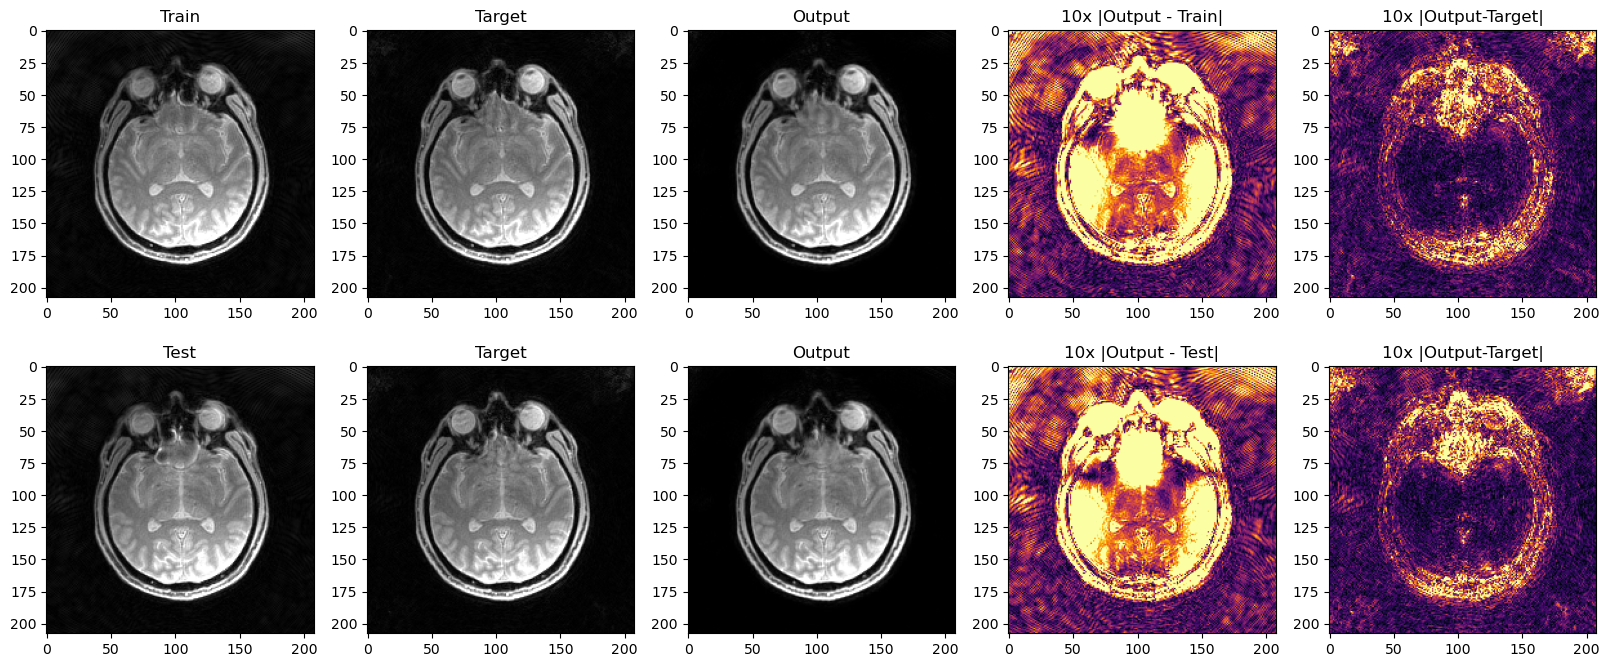

In [36]:
n = [40,41]
model.eval()
tflag = False
dim_order1, dim_order2 = ((1, 0, 2, 3), (2, 1, 0)) if tflag else ((0, 1, 2, 3), (1, 2, 0)) # Transpose

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# test_input = my_dataset.inputs[n]
test_input = img_girf[1, ...]
test_input = test_input[..., n] / sf
test_input = np.transpose(np.stack((np.real(test_input), np.imag(test_input), input_B0[..., n]), axis=3), axes=dim_order1)
# test_input = np.transpose(np.stack((np.real(test_input), np.imag(test_input), np.real(input_Phi[..., n]), np.imag(input_Phi[..., n])), axis=3), axes=dim_order1)
test_input = np.permute_dims(test_input, (2, 3, 0, 1))
test_input = torch.from_numpy(test_input).float()
print(test_input.shape)

# test_input = torch.unsqueeze(test_input, 0)
test_input = test_input.to(device)
with torch.no_grad():
    test_output = model(test_input)
test = test_output.cpu().numpy()
test = test[:, 0, ...] + 1j*test[:, 1, ...]
test = np.permute_dims(test, dim_order2)

plt.figure
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
# axes[0].imshow(np.transpose(np.abs(input_norm[..., n])), vmin=0, vmax=1)
# axes[1].imshow(np.transpose(np.abs(target_norm[..., n])), vmin=0, vmax=1)
axes[0][0].imshow(np.transpose(np.abs(img_girf[1, ..., n[0]])) / sf, vmin=0, vmax=1, cmap='grey')
# axes[0][1].imshow(np.transpose(np.abs(img_MFI_final[0, ..., n[0]])) / sf, vmin=0, vmax=1, cmap='grey')
axes[0][1].imshow(np.transpose(np.abs(img_IR[1, ..., n[0]])) / sf_IR / sf, vmin=0, vmax=1, cmap='grey')
axes[0][2].imshow(np.transpose(np.abs(test[..., 0])), vmin=0, vmax=1, cmap='grey')
axes[0][3].imshow(np.transpose(np.abs(test[..., 0] - img_girf[1, ..., n[0]] / sf)) * 10, vmin=0, vmax=1, cmap='inferno')
# axes[0][4].imshow(np.transpose(np.abs(test[..., 0] - img_MFI_final[0, ..., n[0]] / sf)) * 10, vmin=0, vmax=1, cmap='inferno')
axes[0][4].imshow(np.transpose(np.abs(test[..., 0] - img_IR[1, ..., n[0]] / sf_IR / sf)) * 10, vmin=0, vmax=1, cmap='inferno')

axes[0][0].set_title('Train')
axes[0][1].set_title('Target')
axes[0][2].set_title('Output')
axes[0][3].set_title('10x |Output - Train|')
axes[0][4].set_title('10x |Output-Target|')

axes[1][0].imshow(np.transpose(np.abs(img_girf[1, ..., n[1]])) / sf, vmin=0, vmax=1, cmap='grey')
# axes[1][1].imshow(np.transpose(np.abs(img_MFI_final[0, ..., n[1]])) / sf, vmin=0, vmax=1, cmap='grey')
axes[1][1].imshow(np.transpose(np.abs(img_IR[1, ..., n[1]])) / sf_IR / sf, vmin=0, vmax=1, cmap='grey')
axes[1][2].imshow(np.transpose(np.abs(test[..., 1])), vmin=0, vmax=1, cmap='grey')
axes[1][3].imshow(np.transpose(np.abs(test[..., 1] - img_girf[1, ..., n[1]] / sf)) * 10, vmin=0, vmax=1, cmap='inferno')
axes[1][4].imshow(np.transpose(np.abs(test[..., 1] - img_IR[1, ..., n[1]] / sf_IR / sf)) * 10, vmin=0, vmax=1, cmap='inferno')

axes[1][0].set_title('Test')
axes[1][1].set_title('Target')
axes[1][2].set_title('Output')
axes[1][3].set_title('10x |Output - Test|')
axes[1][4].set_title('10x |Output-Target|')
plt.show()